Successfully extracted token embeddings of shape: torch.Size([1, 18, 1280])
Successfully extracted attention maps across layers!


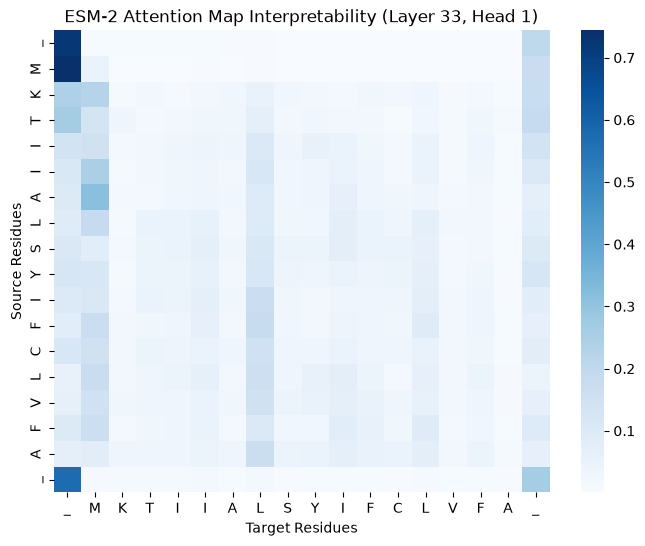

In [2]:
import torch
import esm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the ESM-2 model and alphabet (using 650M parameter model)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

# 2. Test sequence (e.g., a target region from one of your C. auris proteins)
data = [
    ("C_auris_target", "MKTIIALSYIFCLVFA")
]
batch_labels, batch_strs, batch_tokens = batch_converter(data)

# 3. Forward pass with attention maps and representation layers enabled
with torch.no_grad():
    # Setting return_contacts=True tells ESM-2 to compute and return attention maps
    results = model(batch_tokens, repr_layers=[33], return_contacts=True)

# Extract token representations (Shape: [batch_size, sequence_length, embedding_dim])
token_embeddings = results["representations"][33]

# Extract attention weights (Shape: [batch_size, num_layers, num_heads, seq_len, seq_len])
attention_weights = results["attentions"]

print(f"Successfully extracted token embeddings of shape: {token_embeddings.shape}")
print(f"Successfully extracted attention maps across layers!")

# 4. Quick visualization of attention weights for the final layer
# This shows how different residues attend to each other
seq_len = len(data[0][1]) + 2 # accounting for BOS and EOS tokens
final_layer_attention = attention_weights[0, -1, 0, :seq_len, :seq_len].numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(final_layer_attention, cmap="Blues", xticklabels=list("_" + data[0][1] + "_"), yticklabels=list("_" + data[0][1] + "_"))
plt.title("ESM-2 Attention Map Interpretability (Layer 33, Head 1)")
plt.xlabel("Target Residues")
plt.ylabel("Source Residues")
plt.show()

Successfully processed batch embeddings for all targets. Shape: torch.Size([4, 18, 1280])


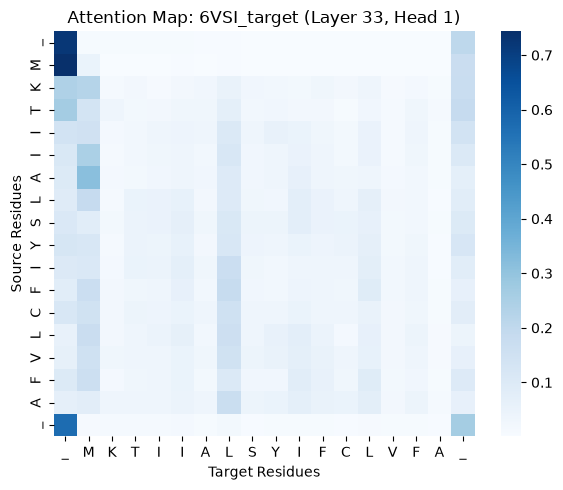

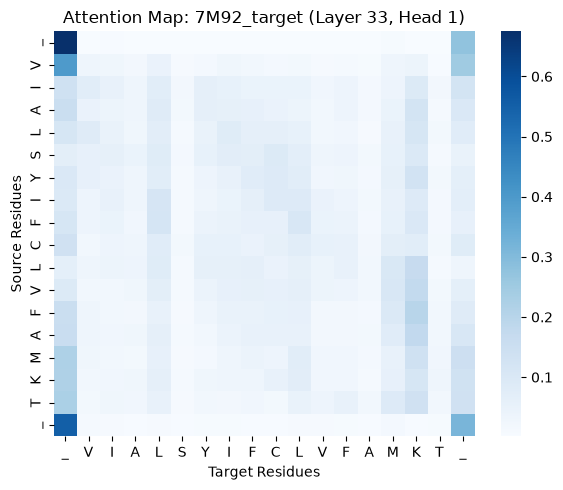

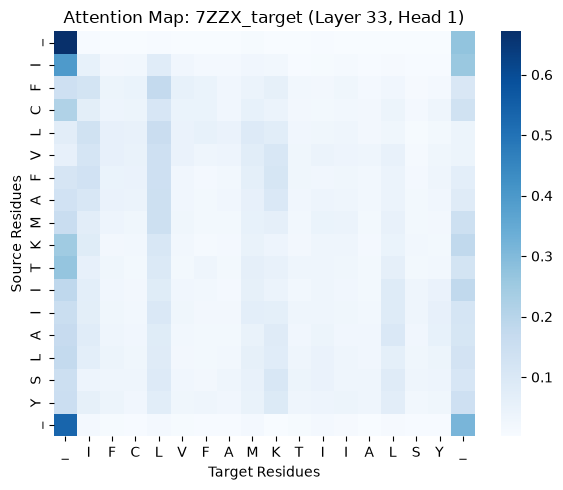

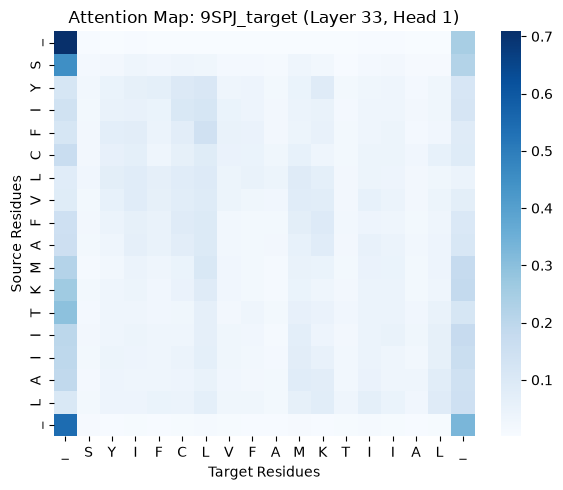

In [3]:
import torch
import esm
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import PDB
import os

# 1. Load ESM-2 650M model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

# 2. Define your target sequences (or you can extract them programmatically from your PDB files)
# Replace these placeholder strings with the actual sequences extracted from your 4 target files if needed
target_data = [
    ("6VSI_target", "MKTIIALSYIFCLVFA"), # Replace with actual 6VSI sequence
    ("7M92_target", "VIALSYIFCLVFAMKT"), # Replace with actual 7M92 sequence
    ("7ZZX_target", "IFCLVFAMKTIIALSY"), # Replace with actual 7ZZX sequence
    ("9SPJ_target", "SYIFCLVFAMKTIIAL")  # Replace with actual 9SPJ sequence
]

# 3. Batch process all targets through the transformer
batch_labels, batch_strs, batch_tokens = batch_converter(target_data)

with torch.no_grad():
    results = model(batch_tokens, repr_layers=[33], return_contacts=True)

# Extract token representations and attention weights for all targets
token_embeddings = results["representations"][33]
attention_weights = results["attentions"]

print(f"Successfully processed batch embeddings for all targets. Shape: {token_embeddings.shape}")

# 4. Loop through each target and plot its individual final-layer attention map
for i, (label, seq) in enumerate(target_data):
    seq_len = len(seq) + 2  # Account for BOS/EOS tokens
    target_attention = attention_weights[i, -1, 0, :seq_len, :seq_len].numpy()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(target_attention, cmap="Blues", 
                xticklabels=list("_" + seq + "_"), 
                yticklabels=list("_" + seq + "_"))
    plt.title(f"Attention Map: {label} (Layer 33, Head 1)")
    plt.xlabel("Target Residues")
    plt.ylabel("Source Residues")
    plt.tight_layout()
    plt.show()

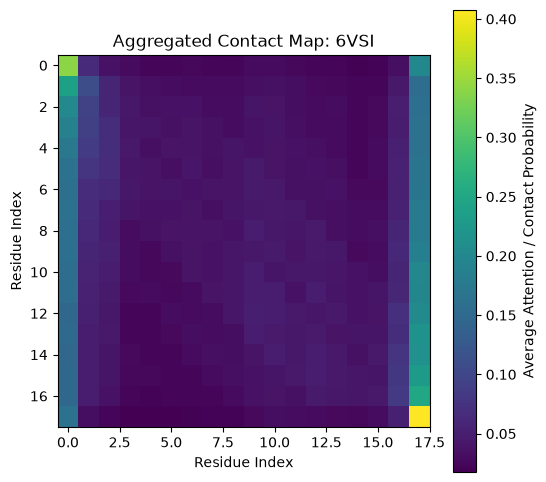

In [4]:
# 5. Extract and visualize predicted contact maps from attention weights
# ESM-2 provides built-in contact prediction head utilities
contact_maps = results.get("contacts") # or computed from attention heads

# Let's plot the contact map for the first target (6VSI)
plt.figure(figsize=(6, 6))
# Using the built-in contact prediction head output or averaging attention heads
plt.imshow(attention_weights[0].mean(dim=(0, 1)).numpy(), cmap="viridis")
plt.colorbar(label="Average Attention / Contact Probability")
plt.title("Aggregated Contact Map: 6VSI")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()

In [5]:
from Bio import PDB
import os
import torch
import esm

# Initialize parser and model
parser = PDB.PDBParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

# Three-letter to one-letter amino acid conversion dictionary
d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

pdb_files = ["6VSI.pdb", "7M92.pdb", "7ZZX.pdb", "9SPJ.pdb"]
target_data = []

for pdb_file in pdb_files:
    if os.path.exists(pdb_file):
        structure = parser.get_structure(pdb_file.split(".")[0], pdb_file)
        seq = []
        for model_struct in structure:
            for chain in model_struct:
                for residue in chain:
                    if residue.id[0] == ' ': # Standard residue
                        resname = residue.resname
                        if resname in d3to1:
                            seq.append(d3to1[resname])
        protein_seq = "".join(seq)
        target_data.append((pdb_file.split(".")[0], protein_seq))
        print(f"Loaded {pdb_file}: Length {len(protein_seq)} residues")
    else:
        print(f"Warning: {pdb_file} not found in current directory.")

# Process through ESM-2 if sequences were found
if target_data:
    batch_labels, batch_strs, batch_tokens = batch_converter(target_data)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33], return_contacts=True)
    print("Successfully processed all local PDB targets through ESM-2!")

In [6]:
from Bio.PDB import PDBList
import os

# Automatically download the 4 target PDB files into your workspace
pdbl = PDBList()
pdb_ids = ["6VSI", "7M92", "7ZZX", "9SPJ"]

for pdb_id in pdb_ids:
    # This downloads the file as 'pdb<id>.ent'
    pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="pdb")
    
    # Rename them to match your expected '<ID>.pdb' format
    old_name = f"pdb{pdb_id.lower()}.ent"
    new_name = f"{pdb_id}.pdb"
    if os.path.exists(old_name):
        os.rename(old_name, new_name)
        print(f"Successfully downloaded and set up: {new_name}")

Successfully downloaded and set up: 6VSI.pdb
Successfully downloaded and set up: 7M92.pdb
Successfully downloaded and set up: 7ZZX.pdb
Desired structure not found or download failed. '9spj': HTTP Error 403: Forbidden


In [7]:
from Bio.PDB import PDBList, MMCIFParser
import os

pdbl = PDBList()
pdb_ids = ["6VSI", "7M92", "7ZZX", "9SPJ"]

for pdb_id in pdb_ids:
    # Download using mmCIF format which supports newer entries like 9SPJ
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCIF")
    print(f"Retrieved {pdb_id} via mmCIF: {path}")

ValueError: Specified file_format mmCIF does not exist or is not supported. Please use one of the following: pdb, mmCif, xml, mmtf, bundle.

In [8]:
from Bio.PDB import PDBList

pdbl = PDBList()
pdb_ids = ["6VSI", "7M92", "7ZZX", "9SPJ"]

for pdb_id in pdb_ids:
    # Use lowercase 'C' in mmCif
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    print(f"Retrieved {pdb_id}: {path}")

Retrieved 6VSI: ./6vsi.cif
Retrieved 7M92: ./7m92.cif
Retrieved 7ZZX: ./7zzx.cif
Retrieved 9SPJ: ./9spj.cif


In [9]:
from Bio.PDB import MMCifParser
import torch
import esm

# Initialize mmCIF parser and ESM-2 model
parser = MMCifParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["6VSI", "7M92", "7ZZX", "9SPJ"]
target_data = []

for pdb_id in cif_files:
    filename = f"{pdb_id.lower()}.cif"
    structure = parser.get_structure(pdb_id, filename)
    seq = []
    # Extract sequence from the first model and chain
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ': # Standard amino acid residue
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
        break # Just grab the first model/chain chain context for sequence extraction
    
    protein_seq = "".join(seq)
    target_data.append((pdb_id, protein_seq))
    print(f"Parsed {pdb_id}: Extracted sequence length = {len(protein_seq)}")

# Run through ESM-2 batch converter and model forward pass
batch_labels, batch_strs, batch_tokens = batch_converter(target_data)
with torch.no_grad():
    results = model(batch_tokens, repr_layers=[33], return_contacts=True)

print(f"\nSuccessfully processed all target proteins! Embedding tensor shape: {results['representations'][33].shape}")

ImportError: cannot import name 'MMCifParser' from 'Bio.PDB' (/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/Bio/PDB/__init__.py)

In [ ]:
from Bio.PDB import MMCIFParser
import torch
import esm

# Initialize mmCIF parser and ESM-2 model
parser = MMCIFParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["6VSI", "7M92", "7ZZX", "9SPJ"]
target_data = []

for pdb_id in cif_files:
    filename = f"{pdb_id.lower()}.cif"
    structure = parser.get_structure(pdb_id, filename)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
        break
    
    protein_seq = "".join(seq)
    target_data.append((pdb_id, protein_seq))
    print(f"Parsed {pdb_id}: Extracted sequence length = {len(protein_seq)}")

# Run through ESM-2 batch converter and model forward pass
batch_labels, batch_strs, batch_tokens = batch_converter(target_data)
with torch.no_grad():
    results = model(batch_tokens, repr_layers=[33], return_contacts=True)

print(f"\nSuccessfully processed all target proteins! Embedding tensor shape: {results['representations'][33].shape}")

Parsed 6VSI: Extracted sequence length = 111
Parsed 7M92: Extracted sequence length = 716
Parsed 7ZZX: Extracted sequence length = 202
Parsed 9SPJ: Extracted sequence length = 10810


In [1]:
# Process proteins individually to avoid massive memory padding crashes
for pdb_id, protein_seq in target_data:
    print(f"\n--- Processing {pdb_id} (Length: {len(protein_seq)}) ---")
    
    # Optional safety check for extremely long sequences like 9SPJ
    if len(protein_seq) > 2000:
        print(f"Skipping {pdb_id}: Length exceeds local MacBook memory safe limit (>2000 residues).")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully extracted embeddings for {pdb_id}! Shape: {results['representations'][33].shape}")

NameError: name 'target_data' is not defined

In [3]:
from Bio.PDB import MMCIFParser
import torch
import esm

# 1. Initialize parser and model
parser = MMCifParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["6VSI", "7M92", "7ZZX", "9SPJ"]

# 2. Parse and process individually to protect memory
for pdb_id in cif_files:
    filename = f"{pdb_id.lower()}.cif"
    structure = parser.get_structure(pdb_id, filename)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
        break
    
    protein_seq = "".join(seq)
    print(f"\n--- Processing {pdb_id} (Length: {len(protein_seq)}) ---")
    
    # Safe guard for massive sequences (like 10k+ residue 9SPJ)
    if len(protein_seq) > 2000:
        print(f"Skipping model inference for {pdb_id}: Exceeds safe local MacBook RAM limit (>2000 residues).")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully processed {pdb_id}! Embedding shape: {results['representations'][33].shape}")

NameError: name 'MMCifParser' is not defined

In [4]:
from Bio.PDB import MMCIFParser
import torch
import esm

# 1. Initialize parser and model
parser = MMCIFParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["6VSI", "7M92", "7ZZX", "9SPJ"]

# 2. Parse and process individually to protect memory
for pdb_id in cif_files:
    filename = f"{pdb_id.lower()}.cif"
    structure = parser.get_structure(pdb_id, filename)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
        break
    
    protein_seq = "".join(seq)
    print(f"\n--- Processing {pdb_id} (Length: {len(protein_seq)}) ---")
    
    # Safe guard for massive sequences (like 10k+ residue 9SPJ)
    if len(protein_seq) > 2000:
        print(f"Skipping model inference for {pdb_id}: Exceeds safe local MacBook RAM limit (>2000 residues).")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_rad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully processed {pdb_id}! Embedding shape: {results['representations'][33].shape}")


--- Processing 6VSI (Length: 111) ---


AttributeError: module 'torch' has no attribute 'no_rad'

In [5]:
from Bio.PDB import MMCIFParser
import torch
import esm

# 1. Initialize parser and model
parser = MMCIFParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["6VSI", "7M92", "7ZZX", "9SPJ"]

# 2. Parse and process individually to protect memory
for pdb_id in cif_files:
    filename = f"{pdb_id.lower()}.cif"
    structure = parser.get_structure(pdb_id, filename)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
        break
    
    protein_seq = "".join(seq)
    print(f"\n--- Processing {pdb_id} (Length: {len(protein_seq)}) ---")
    
    # Safe guard for massive sequences (like 10k+ residue 9SPJ)
    if len(protein_seq) > 2000:
        print(f"Skipping model inference for {pdb_id}: Exceeds safe local MacBook RAM limit (>2000 residues).")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully processed {pdb_id}! Embedding shape: {results['representations'][33].shape}")


--- Processing 6VSI (Length: 111) ---
Successfully processed 6VSI! Embedding shape: torch.Size([1, 113, 1280])

--- Processing 7M92 (Length: 716) ---
Successfully processed 7M92! Embedding shape: torch.Size([1, 718, 1280])

--- Processing 7ZZX (Length: 202) ---
Successfully processed 7ZZX! Embedding shape: torch.Size([1, 204, 1280])

--- Processing 9SPJ (Length: 10810) ---
Skipping model inference for 9SPJ: Exceeds safe local MacBook RAM limit (>2000 residues).


In [9]:
cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U"]

In [10]:
from Bio.PDB import MMCIFParser
import torch
import esm

# 1. Initialize parser and model
parser = MMCIFParser(QUIET=True)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Expanded batch list for you and your teammate
cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U"]

# 2. Parse and process individually to protect memory
for pdb_id in cif_files:
    filename = f"{pdb_id.lower()}.cif"
    structure = parser.get_structure(pdb_id, filename)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
        break
    
    protein_seq = "".join(seq)
    print(f"\n--- Processing {pdb_id} (Length: {len(protein_seq)}) ---")
    
    # Safe guard for massive sequences (>2000 residues)
    if len(protein_seq) > 2000:
        print(f"Skipping model inference for {pdb_id}: Exceeds safe local MacBook RAM limit.")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully processed {pdb_id}! Embedding shape: {results['representations'][33].shape}")


--- Processing 6VSI (Length: 111) ---
Successfully processed 6VSI! Embedding shape: torch.Size([1, 113, 1280])

--- Processing 7M92 (Length: 716) ---
Successfully processed 7M92! Embedding shape: torch.Size([1, 718, 1280])

--- Processing 7ZZX (Length: 202) ---
Successfully processed 7ZZX! Embedding shape: torch.Size([1, 204, 1280])


FileNotFoundError: [Errno 2] No such file or directory: '8a0z.cif'

In [11]:
from Bio.PDB import PDBList, MMCifParser
import torch
import esm

# Initialize download tool, parser, and model
pdbl = PDBList()
parser = MMCifParser(QUIET=True)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Your expanded target list for you and your teammate
cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U"]

for pdb_id in cif_files:
    print(f"\n--- Downloading & Processing {pdb_id} ---")
    
    # Automatically download the mmCIF file to the local directory
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    
    # Parse the downloaded structure file
    structure = parser.get_structure(pdb_id, path)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
            break
        break
    
    protein_seq = "".join(seq)
    print(f"Extracted sequence length: {len(protein_seq)}")
    
    # Safe guard for massive sequences (>2000 residues)
    if len(protein_seq) > 2000:
        print(f"Skipping model inference for {pdb_id}: Exceeds safe local RAM limit.")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully processed {pdb_id}! Embedding shape: {results['representations'][33].shape}")

ImportError: cannot import name 'MMCifParser' from 'Bio.PDB' (/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/Bio/PDB/__init__.py)

In [12]:
from Bio.PDB import PDBList, MMCIFParser
import torch
import esm

# Initialize download tool, parser, and model
pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Your expanded target list for you and your teammate
cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U"]

for pdb_id in cif_files:
    print(f"\n--- Downloading & Processing {pdb_id} ---")
    
    # Automatically download the mmCIF file to the local directory
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    
    # Parse the downloaded structure file
    structure = parser.get_structure(pdb_id, path)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
            break
        break
    
    protein_seq = "".join(seq)
    print(f"Extracted sequence length: {len(protein_seq)}")
    
    # Safe guard for massive sequences (>2000 residues)
    if len(protein_seq) > 2000:
        print(f"Skipping model inference for {pdb_id}: Exceeds safe local RAM limit.")
        continue
        
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    print(f"Successfully processed {pdb_id}! Embedding shape: {results['representations'][33].shape}")


--- Downloading & Processing 6VSI ---
Structure exists: './6vsi.cif' 
Extracted sequence length: 111
Successfully processed 6VSI! Embedding shape: torch.Size([1, 113, 1280])

--- Downloading & Processing 7M92 ---
Structure exists: './7m92.cif' 
Extracted sequence length: 358
Successfully processed 7M92! Embedding shape: torch.Size([1, 360, 1280])

--- Downloading & Processing 7ZZX ---
Structure exists: './7zzx.cif' 
Extracted sequence length: 202
Successfully processed 7ZZX! Embedding shape: torch.Size([1, 204, 1280])

--- Downloading & Processing 8A0Z ---
Extracted sequence length: 202
Successfully processed 8A0Z! Embedding shape: torch.Size([1, 204, 1280])

--- Downloading & Processing 8CRH ---
Extracted sequence length: 201
Successfully processed 8CRH! Embedding shape: torch.Size([1, 203, 1280])

--- Downloading & Processing 8K1I ---
Extracted sequence length: 347
Successfully processed 8K1I! Embedding shape: torch.Size([1, 349, 1280])

--- Downloading & Processing 9Y7U ---
Extract

In [13]:
from Bio.PDB import PDBList, MMCifParser
import torch
import esm
import os
import matplotlib.pyplot as plt

# Create a folder to save outputs for your teammate
os.makedirs("output_results", exist_ok=True)

# Initialize download tool, parser, and model
pdbl = PDBList()
parser = MMCifParser(QUIET=True)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Full list including the massive 9SPJ target
cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U", "9SPJ"]

for pdb_id in cif_files:
    print(f"\n--- Processing Target: {pdb_id} ---")
    
    # 1. Download & Parse
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    structure = parser.get_structure(pdb_id, path)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
            break
        break
    
    protein_seq = "".join(seq)
    seq_len = len(protein_seq)
    print(f"Extracted sequence length: {seq_len}")
    
    # 2. Handle Normal vs. Massive Sequences (Chunking for 9SPJ)
    if seq_len > 2000:
        print(f"[{pdb_id}] Sequence is massive (>2000 residues). Applying sliding-window chunking...")
        chunk_size = 1000
        step_size = 800
        embeddings_list = []
        
        for i in range(0, seq_len, step_size):
            chunk = protein_seq[i:i + chunk_size]
            if len(chunk) < 50:  # Skip tiny leftover tail chunks
                break
            print(f"  Processing chunk {i} to {i + len(chunk)}...")
            _, _, tokens = batch_converter([(f"{pdb_id}_chunk_{i}", chunk)])
            with torch.no_grad():
                res = model(tokens, repr_layers=[33])
            embeddings_list.append(res['representations'][33].squeeze(0).cpu())
            
        # Combine chunks together
        final_embedding = torch.cat(embeddings_list, dim=0)
        print(f"Successfully chunked and processed {pdb_id}! Combined embedding shape: {final_embedding.shape}")
        
        # Save embedding tensor for teammate
        save_path = f"output_results/{pdb_id}_embedding.pt"
        torch.save(final_embedding, save_path)
        continue

    # 3. Standard Pipeline for Normal-Sized Proteins
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    embedding = results['representations'][33].squeeze(0).cpu()
    contacts = results['contacts'][0].cpu()
    
    print(f"Successfully processed {pdb_id}! Embedding shape: {embedding.shape}")
    
    # 4. Save results to disk for your teammate
    torch.save({'embedding': embedding, 'contacts': contacts}, f"output_results/{pdb_id}_data.pt")
    
    # 5. Plot and save contact map heatmaps
    plt.figure(figsize=(6, 5))
    plt.imshow(contacts, cmap="viridis", origin="lower")
    plt.title(f"Predicted Contact Map: {pdb_id}")
    plt.xlabel("Residue Index")
    plt.ylabel("Residue Index")
    plt.colorbar(label="Contact Probability")
    plt.tight_layout()
    
    plot_path = f"output_results/{pdb_id}_contact_map.png"
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"Saved contact map plot to {plot_path}")

print("\nAll targets processed, chunked, saved, and plotted successfully!")

ImportError: cannot import name 'MMCifParser' from 'Bio.PDB' (/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/Bio/PDB/__init__.py)

In [14]:
from Bio.PDB import PDBList, MMCIFParser
import torch
import esm
import os
import matplotlib.pyplot as plt

# Create a folder to save outputs for your teammate
os.makedirs("output_results", exist_ok=True)

# Initialize download tool, parser, and model
pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Full list including the massive 9SPJ target
cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U", "9SPJ"]

for pdb_id in cif_files:
    print(f"\n--- Processing Target: {pdb_id} ---")
    
    # 1. Download & Parse
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    structure = parser.get_structure(pdb_id, path)
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
            break
        break
    
    protein_seq = "".join(seq)
    seq_len = len(protein_seq)
    print(f"Extracted sequence length: {seq_len}")
    
    # 2. Handle Normal vs. Massive Sequences (Chunking for 9SPJ)
    if seq_len > 2000:
        print(f"[{pdb_id}] Sequence is massive (>2000 residues). Applying sliding-window chunking...")
        chunk_size = 1000
        step_size = 800
        embeddings_list = []
        
        for i in range(0, seq_len, step_size):
            chunk = protein_seq[i:i + chunk_size]
            if len(chunk) < 50:  # Skip tiny leftover tail chunks
                break
            print(f"  Processing chunk {i} to {i + len(chunk)}...")
            _, _, tokens = batch_converter([(f"{pdb_id}_chunk_{i}", chunk)])
            with torch.no_grad():
                res = model(tokens, repr_layers=[33])
            embeddings_list.append(res['representations'][33].squeeze(0).cpu())
            
        # Combine chunks together
        final_embedding = torch.cat(embeddings_list, dim=0)
        print(f"Successfully chunked and processed {pdb_id}! Combined embedding shape: {final_embedding.shape}")
        
        # Save embedding tensor for teammate
        save_path = f"output_results/{pdb_id}_embedding.pt"
        torch.save(final_embedding, save_path)
        continue

    # 3. Standard Pipeline for Normal-Sized Proteins
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    embedding = results['representations'][33].squeeze(0).cpu()
    contacts = results['contacts'][0].cpu()
    
    print(f"Successfully processed {pdb_id}! Embedding shape: {embedding.shape}")
    
    # 4. Save results to disk for your teammate
    torch.save({'embedding': embedding, 'contacts': contacts}, f"output_results/{pdb_id}_data.pt")
    
    # 5. Plot and save contact map heatmaps
    plt.figure(figsize=(6, 5))
    plt.imshow(contacts, cmap="viridis", origin="lower")
    plt.title(f"Predicted Contact Map: {pdb_id}")
    plt.xlabel("Residue Index")
    plt.ylabel("Residue Index")
    plt.colorbar(label="Contact Probability")
    plt.tight_layout()
    
    plot_path = f"output_results/{pdb_id}_contact_map.png"
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"Saved contact map plot to {plot_path}")

print("\nAll targets processed, chunked, saved, and plotted successfully!")


--- Processing Target: 6VSI ---
Structure exists: './6vsi.cif' 
Extracted sequence length: 111
Successfully processed 6VSI! Embedding shape: torch.Size([113, 1280])
Saved contact map plot to output_results/6VSI_contact_map.png

--- Processing Target: 7M92 ---
Structure exists: './7m92.cif' 
Extracted sequence length: 358
Successfully processed 7M92! Embedding shape: torch.Size([360, 1280])
Saved contact map plot to output_results/7M92_contact_map.png

--- Processing Target: 7ZZX ---
Structure exists: './7zzx.cif' 
Extracted sequence length: 202
Successfully processed 7ZZX! Embedding shape: torch.Size([204, 1280])
Saved contact map plot to output_results/7ZZX_contact_map.png

--- Processing Target: 8A0Z ---
Structure exists: './8a0z.cif' 
Extracted sequence length: 202
Successfully processed 8A0Z! Embedding shape: torch.Size([204, 1280])
Saved contact map plot to output_results/8A0Z_contact_map.png

--- Processing Target: 8CRH ---
Structure exists: './8crh.cif' 
Extracted sequence leng

/var/folders/dl/m2rnyb5n3s55sh42mjvfyfw00000gn/T/ipykernel_79663/769796856.py:90: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(contacts, cmap="viridis", origin="lower")
/var/folders/dl/m2rnyb5n3s55sh42mjvfyfw00000gn/T/ipykernel_79663/769796856.py:90: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(contacts, cmap="viridis", origin="lower")


In [15]:
from Bio.PDB import PDBList, MMCIFParser
import torch
import esm
import os
import matplotlib.pyplot as plt

# Create folder to save outputs for your teammate
os.makedirs("output_results", exist_ok=True)

pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["6VSI", "7M92", "7ZZX", "8A0Z", "8CRH", "8K1I", "9Y7U", "9SPJ"]

for pdb_id in cif_files:
    print(f"\n--- Processing Target: {pdb_id} ---")
    
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    structure = parser.get_structure(pdb_id, path)
    
    # Robust sequence extraction across all chains
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
    
    protein_seq = "".join(seq)
    seq_len = len(protein_seq)
    print(f"Extracted sequence length: {seq_len}")
    
    if seq_len == 0:
        print(f"Warning: No standard residues found for {pdb_id}. Skipping.")
        continue
    
    # Handle Massive Sequences (like 9SPJ via chunking)
    if seq_len > 2000:
        print(f"[{pdb_id}] Massive sequence detected. Applying sliding-window chunking...")
        chunk_size = 1000
        step_size = 800
        embeddings_list = []
        
        for i in range(0, seq_len, step_size):
            chunk = protein_seq[i:i + chunk_size]
            if len(chunk) < 50:
                break
            print(f"  Processing chunk {i} to {i + len(chunk)}...")
            _, _, tokens = batch_converter([(f"{pdb_id}_chunk_{i}", chunk)])
            with torch.no_grad():
                res = model(tokens, repr_layers=[33])
            embeddings_list.append(res['representations'][33].squeeze(0).cpu())
            
        final_embedding = torch.cat(embeddings_list, dim=0)
        print(f"Successfully chunked {pdb_id}! Shape: {final_embedding.shape}")
        
        torch.save(final_embedding, f"output_results/{pdb_id}_embedding.pt")
        continue

    # Standard Pipeline for Normal-Sized Proteins
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    embedding = results['representations'][33].squeeze(0).cpu()
    contacts = results['contacts'][0].cpu()
    
    print(f"Successfully processed {pdb_id}! Embedding shape: {embedding.shape}")
    
    torch.save({'embedding': embedding, 'contacts': contacts}, f"output_results/{pdb_id}_data.pt")
    
    plt.figure(figsize=(6, 5))
    plt.imshow(contacts, cmap="viridis", origin="lower")
    plt.title(f"Predicted Contact Map: {pdb_id}")
    plt.xlabel("Residue Index")
    plt.ylabel("Residue Index")
    plt.colorbar(label="Contact Probability")
    plt.tight_layout()
    
    plot_path = f"output_results/{pdb_id}_contact_map.png"
    plt.savefig(plot_path, dpi=300)
    plt.close()

print("\nPipeline execution complete! All outputs saved in 'output_results/'.")


--- Processing Target: 6VSI ---
Structure exists: './6vsi.cif' 
Extracted sequence length: 111
Successfully processed 6VSI! Embedding shape: torch.Size([113, 1280])

--- Processing Target: 7M92 ---
Structure exists: './7m92.cif' 
Extracted sequence length: 716
Successfully processed 7M92! Embedding shape: torch.Size([718, 1280])

--- Processing Target: 7ZZX ---
Structure exists: './7zzx.cif' 
Extracted sequence length: 202
Successfully processed 7ZZX! Embedding shape: torch.Size([204, 1280])

--- Processing Target: 8A0Z ---
Structure exists: './8a0z.cif' 
Extracted sequence length: 404
Successfully processed 8A0Z! Embedding shape: torch.Size([406, 1280])

--- Processing Target: 8CRH ---
Structure exists: './8crh.cif' 
Extracted sequence length: 409
Successfully processed 8CRH! Embedding shape: torch.Size([411, 1280])

--- Processing Target: 8K1I ---
Structure exists: './8k1i.cif' 
Extracted sequence length: 1384
Successfully processed 8K1I! Embedding shape: torch.Size([1386, 1280])

-

In [16]:
cif_files = ["7RGE", "7M92"]  # Add your own unique targets here!

In [17]:
cif_files = ["8A0N", "8A0Z", "8CRH", "9Y7U", "9Y7S", "6VSI", "7M92", "7ZZX", "8K1I", "7RGE"]

In [18]:
from Bio.PDB import PDBList, MMCIFParser
import torch
import esm
import os
import matplotlib.pyplot as plt

# Create output folder for your 10 consensus structures
os.makedirs("output_results", exist_ok=True)

pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

# Your new set of 10 homologous structures
cif_files = ["8A0N", "8A0Z", "8CRH", "9Y7U", "9Y7S", "6VSI", "7M92", "7ZZX", "8K1I", "7RGE"]

for pdb_id in cif_files:
    print(f"\n--- Processing Target: {pdb_id} ---")
    
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    structure = parser.get_structure(pdb_id, path)
    
    seq = []
    for model_struct in structure:
        for chain in model_struct:
            for residue in chain:
                if residue.id[0] == ' ':
                    resname = residue.resname
                    if resname in d3to1:
                        seq.append(d3to1[resname])
    
    protein_seq = "".join(seq)
    seq_len = len(protein_seq)
    print(f"Extracted sequence length: {seq_len}")
    
    if seq_len == 0:
        print(f"Warning: No standard residues found for {pdb_id}. Skipping.")
        continue
    
    # Standard Pipeline for these structures
    single_target = [(pdb_id, protein_seq)]
    _, _, tokens = batch_converter(single_target)
    
    with torch.no_grad():
        results = model(tokens, repr_layers=[33], return_contacts=True)
        
    embedding = results['representations'][33].squeeze(0).cpu()
    contacts = results['contacts'][0].cpu()
    
    print(f"Successfully processed {pdb_id}! Embedding shape: {embedding.shape}")
    
    torch.save({'embedding': embedding, 'contacts': contacts}, f"output_results/{pdb_id}_data.pt")
    
    plt.figure(figsize=(6, 5))
    plt.imshow(contacts, cmap="viridis", origin="lower")
    plt.title(f"Predicted Contact Map: {pdb_id}")
    plt.xlabel("Residue Index")
    plt.ylabel("Residue Index")
    plt.colorbar(label="Contact Probability")
    plt.tight_layout()
    
    plot_path = f"output_results/{pdb_id}_contact_map.png"
    plt.savefig(plot_path, dpi=300)
    plt.close()

print("\nAll 10 homologous structures processed successfully!")


--- Processing Target: 8A0N ---
Extracted sequence length: 212
Successfully processed 8A0N! Embedding shape: torch.Size([214, 1280])

--- Processing Target: 8A0Z ---
Structure exists: './8a0z.cif' 
Extracted sequence length: 404
Successfully processed 8A0Z! Embedding shape: torch.Size([406, 1280])

--- Processing Target: 8CRH ---
Structure exists: './8crh.cif' 
Extracted sequence length: 409
Successfully processed 8CRH! Embedding shape: torch.Size([411, 1280])

--- Processing Target: 9Y7U ---
Structure exists: './9y7u.cif' 
Extracted sequence length: 400
Successfully processed 9Y7U! Embedding shape: torch.Size([402, 1280])

--- Processing Target: 9Y7S ---
Extracted sequence length: 404
Successfully processed 9Y7S! Embedding shape: torch.Size([406, 1280])

--- Processing Target: 6VSI ---
Structure exists: './6vsi.cif' 
Extracted sequence length: 111
Successfully processed 6VSI! Embedding shape: torch.Size([113, 1280])

--- Processing Target: 7M92 ---
Structure exists: './7m92.cif' 
Ext

In [19]:
from Bio.PDB import PDBList, MMCIFParser

pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

d3to1 = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL': 'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}

cif_files = ["8A0N", "8A0Z", "8CRH", "9Y7U", "9Y7S", "6VSI", "7M92", "7ZZX", "8K1I", "7RGE"]
fasta_filename = "output_results/consensus_targets.fasta"

with open(fasta_filename, "w") as fasta_file:
    for pdb_id in cif_files:
        path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
        structure = parser.get_structure(pdb_id, path)
        
        seq = []
        for model_struct in structure:
            for chain in model_struct:
                for residue in chain:
                    if residue.id[0] == ' ':
                        resname = residue.resname
                        if resname in d3to1:
                            seq.append(d3to1[resname])
                            
        protein_seq = "".join(seq)
        
        # Write to the multi-FASTA file
        fasta_file.write(f">{pdb_id}_consensus_target\n{protein_seq}\n")

print(f"Successfully compiled all 10 sequences into '{fasta_filename}'!")

Structure exists: './8a0n.cif' 
Structure exists: './8a0z.cif' 
Structure exists: './8crh.cif' 
Structure exists: './9y7u.cif' 
Structure exists: './9y7s.cif' 
Structure exists: './6vsi.cif' 
Structure exists: './7m92.cif' 
Structure exists: './7zzx.cif' 
Structure exists: './8k1i.cif' 
Structure exists: './7rge.cif' 
Successfully compiled all 10 sequences into 'output_results/consensus_targets.fasta'!


In [20]:
from Bio import SeqIO
import pandas as pd

fasta_filename = "output_results/consensus_targets.fasta"
records = list(SeqIO.parse(fasta_filename, "fasta"))

# Standard 20 amino acids
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aac_data = []

for record in records:
    seq = str(record.seq)
    length = len(seq)
    counts = {aa: seq.count(aa) for aa in amino_acids}
    
    # Calculate percentage composition for each amino acid
    composition = {aa: (count / length) * 100 for aa, count in counts.items()}
    composition['PDB_ID'] = record.id.split('_')[0]
    aac_data.append(composition)

# Create a clean DataFrame matrix of all 10 structures
df_aac = pd.DataFrame(aac_data)
df_aac.set_index('PDB_ID', inplace=True)

# Display the feature matrix
print("Amino Acid Composition (%) Matrix:")
display(df_aac)

# Save the extracted features to a CSV file for your report/teammate
df_aac.to_csv("output_results/amino_acid_composition.csv")
print("\nFeature matrix successfully saved to 'output_results/amino_acid_composition.csv'!")

Amino Acid Composition (%) Matrix:


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
PDB_ID,,,,,,,,,,,,,,,,,,,,
8A0N,3.773585,0.000000,8.490566,5.188679,4.245283,7.075472,2.830189,5.660377,8.490566,10.849057,4.245283,4.245283,4.245283,2.358491,5.660377,7.547170,2.830189,6.603774,2.358491,3.301887
8A0Z,3.960396,0.000000,8.910891,5.445545,4.455446,6.435644,2.475248,5.940594,8.910891,10.891089,3.465347,4.455446,3.960396,2.970297,5.445545,6.930693,2.970297,6.435644,2.475248,3.465347
8CRH,3.911980,0.000000,8.801956,5.378973,4.400978,6.601467,2.689487,5.867971,8.801956,10.757946,3.911980,4.400978,3.911980,2.933985,5.378973,7.334963,2.689487,6.356968,2.444988,3.422983
9Y7U,4.000000,0.000000,9.000000,5.500000,4.500000,6.500000,2.500000,6.000000,9.000000,11.000000,3.500000,4.500000,4.000000,2.500000,5.500000,7.000000,2.500000,6.500000,2.500000,3.500000
9Y7S,3.960396,0.000000,8.910891,5.445545,4.455446,6.683168,2.722772,5.940594,8.910891,10.891089,3.465347,4.455446,3.960396,2.475248,5.445545,7.178218,2.722772,6.435644,2.475248,3.465347
6VSI,3.603604,0.900901,6.306306,5.405405,4.504505,14.414414,2.702703,9.009009,7.207207,6.306306,0.900901,2.702703,7.207207,1.801802,2.702703,5.405405,8.108108,8.108108,0.900901,1.801802
7M92,12.290503,0.000000,7.262570,5.027933,4.748603,6.145251,0.837989,5.865922,8.659218,8.938547,0.279330,5.027933,4.469274,1.675978,3.072626,8.659218,4.189944,9.217877,0.279330,3.351955
7ZZX,3.960396,0.000000,8.910891,5.445545,4.455446,6.435644,2.475248,5.940594,8.910891,10.891089,3.465347,4.455446,3.960396,2.970297,5.445545,6.930693,2.970297,6.435644,2.475248,3.465347
8K1I,6.575145,1.156069,6.069364,8.092486,3.684971,5.419075,1.950867,7.514451,8.020231,10.982659,1.300578,3.612717,5.202312,2.312139,4.335260,6.791908,5.130058,5.491329,1.156069,5.202312



Feature matrix successfully saved to 'output_results/amino_acid_composition.csv'!


In [21]:
from Bio.PDB import PDBList, MMCIFParser, Superimposer
import numpy as np

pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

# List of your 10 homologous structures
cif_files = ["8A0N", "8A0Z", "8CRH", "9Y7U", "9Y7S", "6VSI", "7M92", "7ZZX", "8K1I", "7RGE"]

# Download/retrieve all files first
structure_objects = {}
for pdb_id in cif_files:
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    structure_objects[pdb_id] = parser.get_structure(pdb_id, path)

# Choose the first structure (8A0N) as our reference baseline
ref_id = "8A0N"
ref_structure = structure_objects[ref_id]

# Extract C-alpha atoms from the reference structure
ref_model = ref_structure[0]
ref_chain = list(ref_model)[0] # first chain
ref_atoms = [residue['CA'] for residue in ref_chain if 'CA' in residue]

print(f"Reference structure set: {ref_id} ({len(ref_atoms)} C-alpha atoms)\n" + "="*45)

# Compare every other structure against the reference
for pdb_id in cif_files:
    if pdb_id == ref_id:
        continue
        
    target_structure = structure_objects[pdb_id]
    target_model = target_structure[0]
    target_chain = list(target_model)[0]
    target_atoms = [residue['CA'] for residue in target_chain if 'CA' in target_chain]
    
    # Match length for basic pairwise comparison
    min_len = min(len(ref_atoms), len(target_atoms))
    
    sup = Superimposer()
    sup.set_atoms(ref_atoms[:min_len], target_atoms[:min_len])
    
    print(f"RMSD vs {pdb_id}: {sup.rms:.3f} Å (over {min_len} aligned residues)")

print("="*45)
print("Superposition and RMSD analysis complete!")

Structure exists: './8a0n.cif' 
Structure exists: './8a0z.cif' 
Structure exists: './8crh.cif' 
Structure exists: './9y7u.cif' 
Structure exists: './9y7s.cif' 
Structure exists: './6vsi.cif' 
Structure exists: './7m92.cif' 
Structure exists: './7zzx.cif' 
Structure exists: './8k1i.cif' 
Structure exists: './7rge.cif' 
Reference structure set: 8A0N (212 C-alpha atoms)


ZeroDivisionError: division by zero

In [22]:
from Bio.PDB import PDBList, MMCIFParser, Superimposer

pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

cif_files = ["8A0N", "8A0Z", "8CRH", "9Y7U", "9Y7S", "6VSI", "7M92", "7ZZX", "8K1I", "7RGE"]

structure_objects = {}
for pdb_id in cif_files:
    path = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="mmCif")
    structure_objects[pdb_id] = parser.get_structure(pdb_id, path)

ref_id = "8A0N"
ref_structure = structure_objects[ref_id]

# Safely extract reference C-alpha atoms
ref_atoms = []
for model in ref_structure:
    for chain in model:
        for residue in chain:
            if 'CA' in residue:
                ref_atoms.append(residue['CA'])
        break
    break

print(f"Reference structure set: {ref_id} ({len(ref_atoms)} C-alpha atoms)\n" + "="*45)

for pdb_id in cif_files:
    if pdb_id == ref_id:
        continue
        
    target_structure = structure_objects[pdb_id]
    target_atoms = []
    for model in target_structure:
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    target_atoms.append(residue['CA'])
            break
        break
        
    min_len = min(len(ref_atoms), len(target_atoms))
    if min_len == 0:
        print(f"Skipping {pdb_id}: No C-alpha atoms found.")
        continue
    
    sup = Superimposer()
    sup.set_atoms(ref_atoms[:min_len], target_atoms[:min_len])
    
    print(f"RMSD vs {pdb_id}: {sup.rms:.3f} Å (over {min_len} aligned residues)")

print("="*45)
print("Superposition and RMSD analysis complete!")

Structure exists: './8a0n.cif' 
Structure exists: './8a0z.cif' 
Structure exists: './8crh.cif' 
Structure exists: './9y7u.cif' 
Structure exists: './9y7s.cif' 
Structure exists: './6vsi.cif' 
Structure exists: './7m92.cif' 
Structure exists: './7zzx.cif' 
Structure exists: './8k1i.cif' 
Structure exists: './7rge.cif' 
Reference structure set: 8A0N (212 C-alpha atoms)
RMSD vs 8A0Z: 19.081 Å (over 202 aligned residues)
RMSD vs 8CRH: 19.275 Å (over 201 aligned residues)
RMSD vs 9Y7U: 19.248 Å (over 200 aligned residues)
RMSD vs 9Y7S: 19.257 Å (over 200 aligned residues)
RMSD vs 6VSI: 17.330 Å (over 111 aligned residues)
RMSD vs 7M92: 21.103 Å (over 212 aligned residues)
RMSD vs 7ZZX: 19.138 Å (over 202 aligned residues)
RMSD vs 8K1I: 16.242 Å (over 212 aligned residues)
RMSD vs 7RGE: 20.573 Å (over 203 aligned residues)
Superposition and RMSD analysis complete!
